In [1]:
import math

import matplotlib.pyplot as plt
import opensim as osim

In [2]:
model = osim.Model()
model.setName("model")

In [3]:
# Create a pendulum model.
# ------------------------
# In the default pose, the system is a mass hanging 1 meter down from a hinge.
body = osim.Body("body", 1.0, osim.Vec3(0), osim.Inertia(1))
model.addComponent(body)

joint = osim.PinJoint(
    "joint", model.getGround(), osim.Vec3(0), osim.Vec3(0), body, osim.Vec3(0, 1.0, 0), osim.Vec3(0)
)
joint.updCoordinate().setName("q")
model.addComponent(joint)

In [4]:
# This reporter will collect states throughout the simulation at intervals of
# 0.05 seconds.
reporter = osim.StatesTrajectoryReporter()
reporter.setName("reporter")
reporter.set_report_time_interval(0.05)
model.addComponent(reporter)

In [5]:
# Simulate.
# ---------
state = model.initSystem()

# The initial position is that the pendulum is rotated 45 degrees
# counter-clockwise from its default pose.
model.setStateVariableValue(state, "joint/q/value", 0.25 * math.pi)

manager = osim.Manager(model, state)
manager.integrate(10.0)

<opensim.simbody.State; proxy of <Swig Object of type 'SimTK::State *' at 0x7ceb543cb930> >

In [6]:
# Analyze the simulation.
# -----------------------
# Retrieve the StatesTrajectory from the reporter.
statesTraj = reporter.getStates()

for itime in range(statesTraj.getSize()):
    state = statesTraj[itime]
    time = state.getTime()
    q = model.getStateVariableValue(state, "joint/q/value")

    # Calculating joint reactions requires realizing to Acceleration.
    model.realizeAcceleration(state)
    # This returns a SpatialVec, which is two Vec3's ([0]: moment, [1]: force).
    reaction = joint.calcReactionOnParentExpressedInGround(state)
    force = reaction.get(1)
    force_mag = math.sqrt(force[0] ** 2 + force[1] ** 2 + force[2] ** 2)
    print("time: %f s.  q: %f rad.  reaction force magnitude: %f N." % (time, q, force_mag))

    # The reaction could also be accessed as an output:
    # abstractOutput = joint.getOutput('reaction_on_parent')
    # output = osim.OutputSpatialVec.safeDownCast(abstractOutput)
    # outputValue = output.getValue(s)

time: 0.000000 s.  q: 0.785398 rad.  reaction force magnitude: 7.752838 N.
time: 0.050000 s.  q: 0.781067 rad.  reaction force magnitude: 7.799818 N.
time: 0.100000 s.  q: 0.768073 rad.  reaction force magnitude: 7.940176 N.
time: 0.150000 s.  q: 0.746531 rad.  reaction force magnitude: 8.171302 N.
time: 0.200000 s.  q: 0.716727 rad.  reaction force magnitude: 8.487457 N.
time: 0.250000 s.  q: 0.678954 rad.  reaction force magnitude: 8.879773 N.
time: 0.300000 s.  q: 0.633502 rad.  reaction force magnitude: 9.335682 N.
time: 0.350000 s.  q: 0.580658 rad.  reaction force magnitude: 9.838255 N.
time: 0.400000 s.  q: 0.520979 rad.  reaction force magnitude: 10.365251 N.
time: 0.450000 s.  q: 0.455260 rad.  reaction force magnitude: 10.891869 N.
time: 0.500000 s.  q: 0.384302 rad.  reaction force magnitude: 11.392189 N.
time: 0.550000 s.  q: 0.308905 rad.  reaction force magnitude: 11.840399 N.
time: 0.600000 s.  q: 0.229868 rad.  reaction force magnitude: 12.212050 N.
time: 0.650000 s.  q

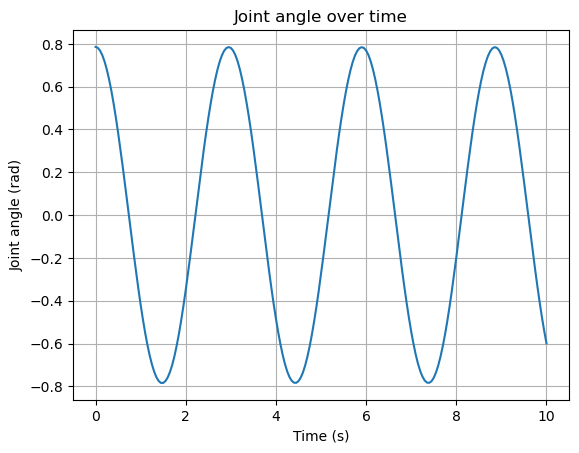

In [7]:
# Plot the reporter's data.
times = [state.getTime() for state in statesTraj]
qs = [model.getStateVariableValue(state, "joint/q/value") for state in statesTraj]

plt.plot(times, qs)
plt.xlabel("Time (s)")
plt.ylabel("Joint angle (rad)")
plt.title("Joint angle over time")
plt.grid()
plt.show()

In [8]:
# Alternately, we could load a StatesTrajectory from a TimeSeriesTable file
# using StatesTrajectory.createFromStatesTable().
statesTable = manager.getStatesTable()
statesTraj2 = osim.StatesTrajectory.createFromStatesTable(model, statesTable)

for itime in range(statesTraj2.getSize()):
    state = statesTraj2[itime]
    time = state.getTime()
    u = model.getStateVariableValue(state, "joint/q/speed")
    print("time: %f s.  u: %f rad/s." % (time, u))

time: 0.000000 s.  u: 0.000000 rad/s.
time: 0.010000 s.  u: -0.034670 rad/s.
time: 0.060000 s.  u: -0.207597 rad/s.
time: 0.310000 s.  u: -1.013314 rad/s.
time: 0.670791 s.  u: -1.676142 rad/s.
time: 1.031583 s.  u: -1.355405 rad/s.
time: 1.392374 s.  u: -0.288887 rad/s.
time: 1.753165 s.  u: 0.916503 rad/s.
time: 2.058849 s.  u: 1.595961 rad/s.
time: 2.420395 s.  u: 1.522307 rad/s.
time: 2.781940 s.  u: 0.579901 rad/s.
time: 3.143486 s.  u: -0.648422 rad/s.
time: 3.505032 s.  u: -1.554800 rad/s.
time: 3.878340 s.  u: -1.550346 rad/s.
time: 4.251648 s.  u: -0.601091 rad/s.
time: 4.624957 s.  u: 0.665195 rad/s.
time: 4.998265 s.  u: 1.578320 rad/s.
time: 5.356345 s.  u: 1.547223 rad/s.
time: 5.714424 s.  u: 0.644446 rad/s.
time: 6.072504 s.  u: -0.572030 rad/s.
time: 6.430584 s.  u: -1.512135 rad/s.
time: 6.784674 s.  u: -1.610318 rad/s.
time: 7.138764 s.  u: -0.808376 rad/s.
time: 7.492854 s.  u: 0.385899 rad/s.
time: 7.846944 s.  u: 1.400793 rad/s.
time: 8.188158 s.  u: 1.672692 rad/s